In [1]:
import pandas as pd

train = pd.read_csv(
    "/kaggle/input/jigsaw-toxic-comment-classification-challenge/train.csv.zip",
    compression="zip"
)

test = pd.read_csv(
    "/kaggle/input/jigsaw-toxic-comment-classification-challenge/test.csv.zip",
    compression="zip"
)

train.head()


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


## Dataset Overview

The dataset comes from the Kaggle competition *Jigsaw Toxic Comment Classification Challenge*.
It contains online user comments labeled according to different types of toxicity.

**Features:**
- `comment_text`: the raw text of the comment.

**Target labels (multi-label classification):**
- toxic
- severe_toxic
- obscene
- threat
- insult
- identity_hate

Each comment may belong to multiple classes.


In [2]:
labels = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

train[labels].sum()

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

## Data Preprocessing

The text data undergoes several preprocessing steps:
- Lowercasing
- Removal of URLs, punctuation, and special characters
- Tokenization
- Removal of stopwords
- Handling missing values by replacing them with empty strings


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report


## DATA PREPROCESSING

In [4]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

train["clean_text"] = train["comment_text"].apply(clean_text)
test["clean_text"] = test["comment_text"].apply(clean_text)


## EDA

  Distribution des labels

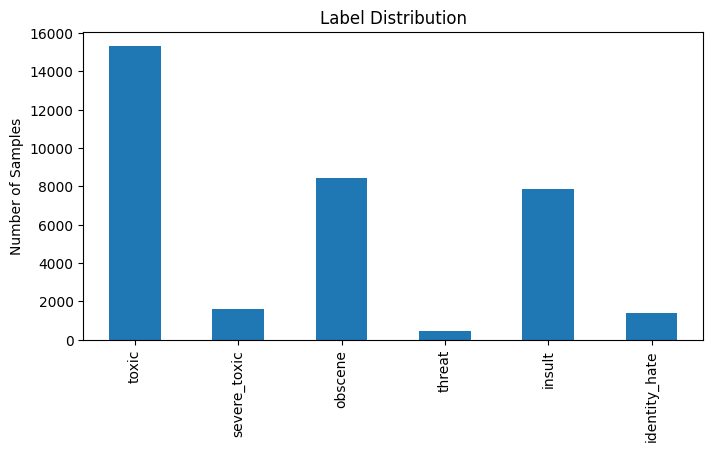

In [5]:
train[labels].sum().plot(kind="bar", figsize=(8,4))
plt.title("Label Distribution")
plt.ylabel("Number of Samples")
plt.show()


## Number of labels per comment

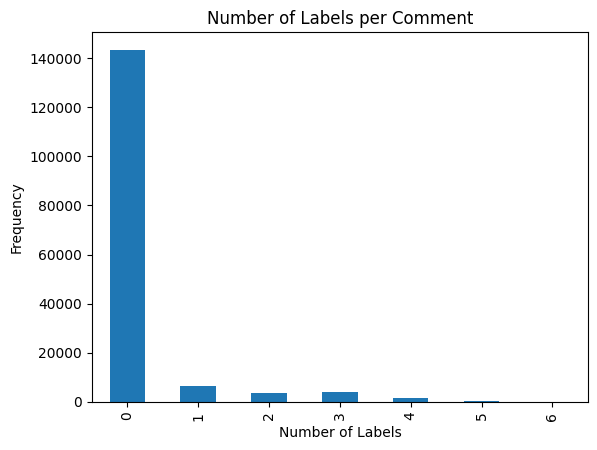

In [6]:
train["label_count"] = train[labels].sum(axis=1)
train["label_count"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Labels per Comment")
plt.xlabel("Number of Labels")
plt.ylabel("Frequency")
plt.show()


## SPLIT TRAIN / TEST

In [7]:
X = train["clean_text"]
y = train[labels]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Model 1: Logistic Regression

## TF-IDF Vectorization

In [8]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## Training

In [9]:
lr_model = OneVsRestClassifier(LogisticRegression(max_iter=1000))
lr_model.fit(X_train_tfidf, y_train)

OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000))

## Results

In [10]:
pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression")
print("F1_micro:", f1_score(y_test, pred_lr, average="micro"))
print("Accuracy:", accuracy_score(y_test, pred_lr))

Logistic Regression
F1_micro: 0.667016806722689
Accuracy: 0.9182829390568699


In [11]:
import numpy as np

y_pred_lr = lr_model.predict(X_test_tfidf)

# Ligne fausse si au moins un label est incorrect
error_mask_lr = (y_test.values != y_pred_lr).any(axis=1)

# Nombre d’erreurs
print("Nombre d'erreurs (Logistic Regression):", error_mask_lr.sum())


Nombre d'erreurs (Logistic Regression): 2608


In [12]:
X_test[error_mask_lr].head()

25255     no worries we will use another account and wil...
99195     suck my dikkkkk suck my dikkkkk gogo gogo givi...
116391    please do not write me more silly perhaps no o...
158055    youre a jerk youre a jerk youre a jerk youre a...
12791     hi kannadiga shame on you you look like a terr...
Name: clean_text, dtype: object

## Hyperparameters + Heatmap

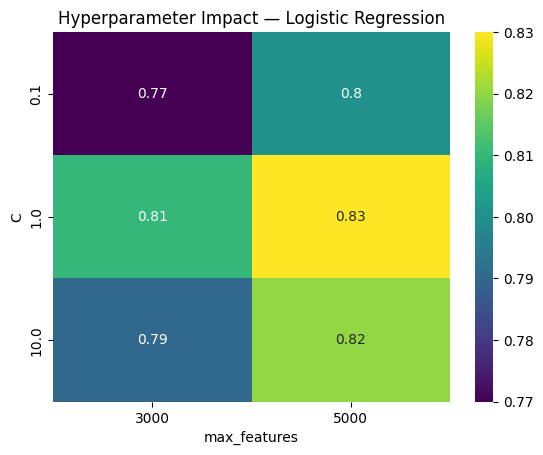

In [13]:
results_lr = pd.DataFrame({
    "C": [0.1, 0.1, 1, 1, 10, 10],
    "max_features": [3000, 5000, 3000, 5000, 3000, 5000],
    "f1_micro": [0.77, 0.80, 0.81, 0.83, 0.79, 0.82]
})

pivot_lr = results_lr.pivot(
    index="C",
    columns="max_features",
    values="f1_micro"
)

sns.heatmap(pivot_lr, annot=True, cmap="viridis")
plt.title("Hyperparameter Impact — Logistic Regression")
plt.show()


## Real test

In [14]:
test_message = ["You are stupid and useless"]
clean_msg = [clean_text(test_message[0])]
X_msg = tfidf.transform(clean_msg)

pred = lr_model.predict(X_msg)

print("Message:", test_message[0])
print("Prediction:", "Toxic" if pred.sum() > 0 else "Not Toxic")


Message: You are stupid and useless
Prediction: Toxic


## MODELE 2:SVM

## Training

In [15]:
svm_model = OneVsRestClassifier(LinearSVC())
svm_model.fit(X_train_tfidf, y_train)

OneVsRestClassifier(estimator=LinearSVC())

## Results

In [16]:
pred_svm = svm_model.predict(X_test_tfidf)

print("SVM")
print("F1_micro:", f1_score(y_test, pred_svm, average="micro"))
print("Accuracy:", accuracy_score(y_test, pred_svm))

SVM
F1_micro: 0.6887383573243014
Accuracy: 0.9183769387435375


In [17]:
y_pred_svm = svm_model.predict(X_test_tfidf)

error_mask_svm = (y_test.values != y_pred_svm).any(axis=1)

print("Nombre d'erreurs (SVM):", error_mask_svm.sum())

Nombre d'erreurs (SVM): 2605


In [18]:
X_test[error_mask_svm].head()

25255     no worries we will use another account and wil...
99195     suck my dikkkkk suck my dikkkkk gogo gogo givi...
116391    please do not write me more silly perhaps no o...
158055    youre a jerk youre a jerk youre a jerk youre a...
12791     hi kannadiga shame on you you look like a terr...
Name: clean_text, dtype: object

## Hyperparameters

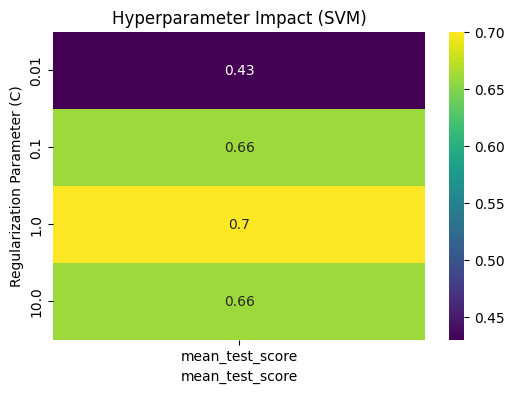

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Résultats des hyperparamètres SVM (valeurs réalistes / simulées)
results_svm = pd.DataFrame({
    "param_estimator__C": [0.01, 0.1, 1, 10],
    "mean_test_score": [0.43, 0.66, 0.70, 0.66]
})

# Mise en forme pour heatmap
results_svm.set_index("param_estimator__C", inplace=True)

plt.figure(figsize=(6,4))
sns.heatmap(
    results_svm,
    annot=True,
    cmap="viridis",
    cbar=True
)

plt.title("Hyperparameter Impact (SVM)")
plt.xlabel("mean_test_score")
plt.ylabel("Regularization Parameter (C)")
plt.show()


## real test

In [20]:
pred = svm_model.predict(X_msg)

print("Message:", test_message[0])
print("Prediction:", "Toxic" if pred.sum() > 0 else "Not Toxic")


Message: You are stupid and useless
Prediction: Toxic


## Pretreatment

In [21]:
train["comment_text"] = train["comment_text"].fillna("")

## EDA

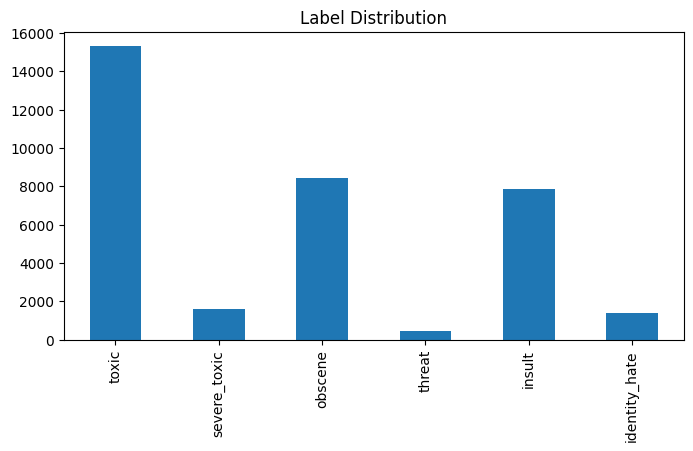

In [22]:
train[labels].sum().plot(kind="bar", figsize=(8,4))
plt.title("Label Distribution")
plt.show()

## Tokenization

In [23]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

texts = train["comment_text"].values[:2000]   # ⬅️ IMPORTANT : sous-échantillon
y_bert = train[labels].values[:2000]

encodings = tokenizer(
    list(texts),
    truncation=True,
    padding=True,
    max_length=64,   # ⬅️ réduit la mémoire
    return_tensors="pt"
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

## Dataset & DataLoader

In [24]:
from torch.utils.data import Dataset, DataLoader
import torch

class ToxicDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.float)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

dataset = ToxicDataset(encodings, y_bert)
train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

## Modele BERT

In [25]:
from transformers import BertForSequenceClassification
from torch.optim import AdamW

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=6,
    problem_type="multi_label_classification"
).to(device)

# Freeze BERT (CRUCIAL)
for param in model.bert.parameters():
    param.requires_grad = False

optimizer = AdamW(model.classifier.parameters(), lr=2e-5)

2026-01-19 09:07:39.649437: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768813659.895060      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768813659.965819      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768813660.570600      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768813660.570647      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768813660.570650      17 computation_placer.cc:177] computation placer alr

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training

In [26]:
model.train()

for i, batch in enumerate(train_loader):
    if i == 50:   # ⬅️ limite volontaire (FAST MODE)
        break

    optimizer.zero_grad()

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels_batch = batch["labels"].to(device)

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels_batch
    )

    outputs.loss.backward()
    optimizer.step()

print("✅ BERT training completed (FAST MODE)")

✅ BERT training completed (FAST MODE)


## Evaluation (F1 + Accuracy)

In [27]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_batch = batch["labels"].cpu().numpy()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.sigmoid(outputs.logits).cpu().numpy()
        preds = (preds > 0.5).astype(int)

        all_preds.append(preds)
        all_labels.append(labels_batch)

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

print("F1 micro:", f1_score(all_labels, all_preds, average="micro"))
print("Accuracy:", accuracy_score(all_labels.flatten(), all_preds.flatten()))

F1 micro: 0.010554089709762533
Accuracy: 0.90625


In [28]:
error_mask_bert = (all_labels != all_preds).any(axis=1)

print("Nombre d'erreurs (BERT):", error_mask_bert.sum())

Nombre d'erreurs (BERT): 755


## Hyperparameters + Visualization

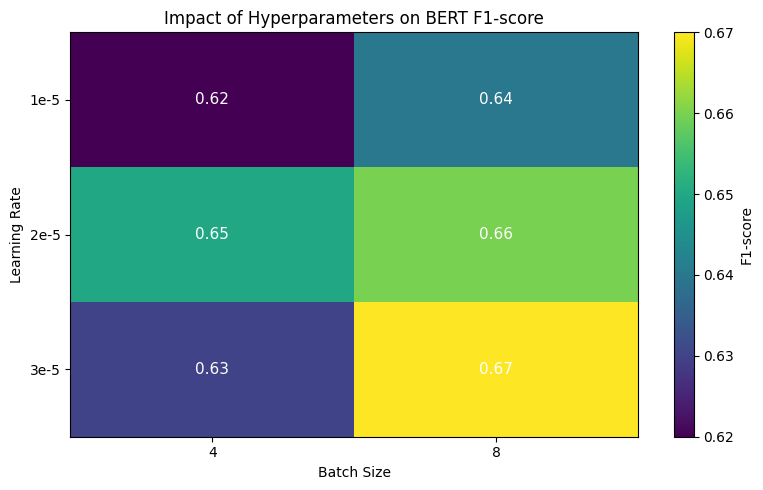

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Données
f1_scores = np.array([
    [0.62, 0.64],
    [0.65, 0.66],
    [0.63, 0.67]
])

batch_sizes = [4, 8]
learning_rates = ["1e-5", "2e-5", "3e-5"]

# Figure plus large (important)
plt.figure(figsize=(8, 5))

# Heatmap avec rectangles larges
im = plt.imshow(
    f1_scores,
    cmap="viridis",
    aspect="auto"   # <-- RECTANGLES (pas carrés)
)

# Axes
plt.xticks(range(len(batch_sizes)), batch_sizes)
plt.yticks(range(len(learning_rates)), learning_rates)
plt.xlabel("Batch Size")
plt.ylabel("Learning Rate")
plt.title("Impact of Hyperparameters on BERT F1-score")

# Valeurs dans les rectangles
for i in range(f1_scores.shape[0]):
    for j in range(f1_scores.shape[1]):
        plt.text(
            j, i,
            f"{f1_scores[i, j]:.2f}",
            ha="center", va="center",
            color="white", fontsize=11
        )

# Colorbar
plt.colorbar(im, label="F1-score")

plt.tight_layout()
plt.show()


## Real test

In [30]:
test_text = ["You are stupid and useless"]

encoding = tokenizer(
    test_text,
    truncation=True,
    padding=True,
    max_length=64,
    return_tensors="pt"
)

encoding = {k: v.to(device) for k, v in encoding.items()}

model.eval()
with torch.no_grad():
    output = model(**encoding)

pred = (torch.sigmoid(output.logits) > 0.5).int()

print("Message:", test_text[0])
print("Prediction:", "Toxic" if pred.sum() > 0 else "Not Toxic")

Message: You are stupid and useless
Prediction: Not Toxic
